In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === DATA PATH - Change this to load from different results folders ===
DATA_DIR = Path('final_results')
# DATA_DIR = Path('.')  # Use current directory

# ICML format settings
# Single column: 3.25in, Full width: 6.75in
ICML_COLUMNWIDTH = 3.25
ICML_TEXTWIDTH = 6.75

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'figure.titlesize': 9,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.3,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})

print(f"Loading data from: {DATA_DIR.resolve()}")

Loading data from: /home/sjbhatt/riemannian-neural-ot/experiments/final_results


In [2]:
# Load sphere data
ours_sphere = np.load(DATA_DIR / 'ours_sweep_sphere.npz')
rcpm_sphere = np.load(DATA_DIR / 'rcpm_sweep_sphere.npz')

dimensions = ours_sphere['dimensions']
gammas = list(rcpm_sphere['gammas'])

# Load torus data
ours_torus = np.load(DATA_DIR / 'ours_sweep_torus.npz')
rcpm_torus = np.load(DATA_DIR / 'rcpm_sweep_torus.npz')

torus_dims = ours_torus['dimensions']
torus_gammas = list(rcpm_torus['gammas'])

Saved: final_results/kl_combined.pdf (6.75in wide)


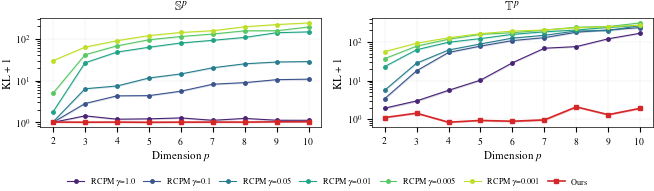

In [3]:
# Combined 1x2 figure - ICML full width format
fig, axes = plt.subplots(1, 2, figsize=(ICML_TEXTWIDTH, 2.0))

# === Sphere (left) ===
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(gammas)))

lines = []
labels = []

for i, gamma in enumerate(gammas):
    kl_vals = rcpm_sphere[f'gamma_{gamma}_kl'] + 1
    kl_errs = rcpm_sphere[f'gamma_{gamma}_kl_errors']
    line, = ax.semilogy(dimensions, kl_vals, 'o-', markersize=2.5, linewidth=0.8,
                        color=colors[i])
    ax.fill_between(dimensions, np.maximum(kl_vals - kl_errs, 1e-6),
                    kl_vals + kl_errs, color=colors[i], alpha=0.15)
    lines.append(line)
    labels.append(r'RCPM $\gamma$=' + str(gamma))

ours_kl = ours_sphere['kl_values'] + 1
ours_err = ours_sphere['kl_errors']
line_ours, = ax.semilogy(dimensions, ours_kl, 's-', markersize=3.5, linewidth=1.2,
                         color='tab:red', zorder=10)
ax.fill_between(dimensions, np.maximum(ours_kl - ours_err, 1e-6),
                ours_kl + ours_err, color='tab:red', alpha=0.2, zorder=9)
lines.append(line_ours)
labels.append('Ours')

ax.set_xlabel(r'Dimension $p$')
ax.set_ylabel(r'KL + 1')
ax.set_title(r'$\mathbb{S}^p$')
ax.grid(True, alpha=0.3, linewidth=0.3)

# === Torus (right) ===
ax = axes[1]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(torus_gammas)))

for i, gamma in enumerate(torus_gammas):
    kl_vals = rcpm_torus[f'gamma_{gamma}_kl'] + 1
    kl_errs = rcpm_torus[f'gamma_{gamma}_kl_errors']
    ax.semilogy(torus_dims, kl_vals, 'o-', markersize=2.5, linewidth=0.8,
                color=colors[i])
    ax.fill_between(torus_dims, np.maximum(kl_vals - kl_errs, 1e-6),
                    kl_vals + kl_errs, color=colors[i], alpha=0.15)

ours_kl = ours_torus['kl_values'] + 1
ours_err = ours_torus['kl_errors']
ax.semilogy(torus_dims, ours_kl, 's-', markersize=3.5, linewidth=1.2,
            color='tab:red', zorder=10)
ax.fill_between(torus_dims, np.maximum(ours_kl - ours_err, 1e-6),
                ours_kl + ours_err, color='tab:red', alpha=0.2, zorder=9)

ax.set_xlabel(r'Dimension $p$')
ax.set_ylabel(r'KL + 1')
ax.set_title(r'$\mathbb{T}^p$')
ax.grid(True, alpha=0.3, linewidth=0.3)

# Shared legend below the plots
fig.legend(lines, labels, loc='lower center', ncol=len(labels), 
           bbox_to_anchor=(0.5, -0.02), frameon=False, columnspacing=1.0)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # Leave space for legend at bottom
plt.savefig(DATA_DIR / 'kl_combined.pdf', bbox_inches='tight', pad_inches=0.02)
plt.savefig(DATA_DIR / 'kl_combined.png', dpi=300, bbox_inches='tight', pad_inches=0.02)
print(f"Saved: {DATA_DIR / 'kl_combined.pdf'} ({ICML_TEXTWIDTH}in wide)")
plt.show()

Saved: final_results/sphere_highD.pdf (3.25in wide)
Ours dimensions: [np.int64(2), np.int64(5), np.int64(10), np.int64(20), np.int64(30), np.int64(40)]
RCPM dimensions: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


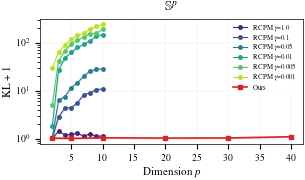

In [4]:
# High-dimensional sphere results (Ours + RCPM)
ours_highD = np.load(DATA_DIR / 'ours_highD_sphere.npz')
rcpm_sphere = np.load(DATA_DIR / 'rcpm_sweep_sphere.npz')

highD_dims = ours_highD['dimensions']
rcpm_dims = rcpm_sphere['dimensions']
gammas = list(rcpm_sphere['gammas'])

fig, ax = plt.subplots(1, 1, figsize=(ICML_COLUMNWIDTH, 2.0))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(gammas)))

lines = []
labels = []

# RCPM for each gamma
for i, gamma in enumerate(gammas):
    kl_vals = rcpm_sphere[f'gamma_{gamma}_kl'] + 1
    kl_errs = rcpm_sphere[f'gamma_{gamma}_kl_errors']
    line, = ax.semilogy(rcpm_dims, kl_vals, 'o-', markersize=2.5, linewidth=0.8,
                        color=colors[i])
    ax.fill_between(rcpm_dims, np.maximum(kl_vals - kl_errs, 1e-6),
                    kl_vals + kl_errs, color=colors[i], alpha=0.15)
    lines.append(line)
    labels.append(r'RCPM $\gamma$=' + str(gamma))

# Ours
highD_kl = ours_highD['kl_values'] + 1
highD_kl_err = ours_highD['kl_errors']
line_ours, = ax.semilogy(highD_dims, highD_kl, 's-', markersize=3.5, linewidth=1.2,
                         color='tab:red', zorder=10)
ax.fill_between(highD_dims, np.maximum(highD_kl - highD_kl_err, 1e-6),
                highD_kl + highD_kl_err, color='tab:red', alpha=0.2, zorder=9)
lines.append(line_ours)
labels.append('Ours')

ax.set_xlabel(r'Dimension $p$')
ax.set_ylabel(r'KL + 1')
ax.set_title(r'$\mathbb{S}^p$')
ax.grid(True, alpha=0.3, linewidth=0.3)

# Legend inside on the right
ax.legend(lines, labels, loc='upper right', frameon=True, fontsize=5, 
          framealpha=0.9, edgecolor='none')

plt.tight_layout()
plt.savefig(DATA_DIR / 'sphere_highD.pdf', bbox_inches='tight', pad_inches=0.02)
plt.savefig(DATA_DIR / 'sphere_highD.png', dpi=300, bbox_inches='tight', pad_inches=0.02)
print(f"Saved: {DATA_DIR / 'sphere_highD.pdf'} ({ICML_COLUMNWIDTH}in wide)")
print(f"Ours dimensions: {list(highD_dims)}")
print(f"RCPM dimensions: {list(rcpm_dims)}")
plt.show()

Saved: final_results/torus_highD.pdf (3.25in wide)
Ours dimensions: [np.int64(2), np.int64(5), np.int64(10), np.int64(20), np.int64(30), np.int64(40)]
RCPM dimensions: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


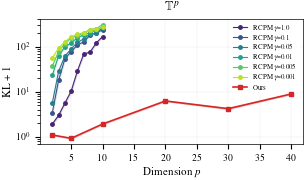

In [5]:
# High-dimensional torus results (Ours + RCPM)
ours_highD = np.load(DATA_DIR / 'ours_highD_torus.npz')
rcpm_torus = np.load(DATA_DIR / 'rcpm_sweep_torus.npz')

highD_dims = ours_highD['dimensions']
rcpm_dims = rcpm_torus['dimensions']
gammas = list(rcpm_torus['gammas'])

fig, ax = plt.subplots(1, 1, figsize=(ICML_COLUMNWIDTH, 2.0))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(gammas)))

lines = []
labels = []

# RCPM for each gamma
for i, gamma in enumerate(gammas):
    kl_vals = rcpm_torus[f'gamma_{gamma}_kl'] + 1
    kl_errs = rcpm_torus[f'gamma_{gamma}_kl_errors']
    line, = ax.semilogy(rcpm_dims, kl_vals, 'o-', markersize=2.5, linewidth=0.8,
                        color=colors[i])
    ax.fill_between(rcpm_dims, np.maximum(kl_vals - kl_errs, 1e-6),
                    kl_vals + kl_errs, color=colors[i], alpha=0.15)
    lines.append(line)
    labels.append(r'RCPM $\gamma$=' + str(gamma))

# Ours
highD_kl = ours_highD['kl_values'] + 1
highD_kl_err = ours_highD['kl_errors']
line_ours, = ax.semilogy(highD_dims, highD_kl, 's-', markersize=3.5, linewidth=1.2,
                         color='tab:red', zorder=10)
ax.fill_between(highD_dims, np.maximum(highD_kl - highD_kl_err, 1e-6),
                highD_kl + highD_kl_err, color='tab:red', alpha=0.2, zorder=9)
lines.append(line_ours)
labels.append('Ours')

ax.set_xlabel(r'Dimension $p$')
ax.set_ylabel(r'KL + 1')
ax.set_title(r'$\mathbb{T}^p$')
ax.grid(True, alpha=0.3, linewidth=0.3)

# Legend inside on the right
ax.legend(lines, labels, loc='upper right', frameon=True, fontsize=5, 
          framealpha=0.9, edgecolor='none')

plt.tight_layout()
plt.savefig(DATA_DIR / 'torus_highD.pdf', bbox_inches='tight', pad_inches=0.02)
plt.savefig(DATA_DIR / 'torus_highD.png', dpi=300, bbox_inches='tight', pad_inches=0.02)
print(f"Saved: {DATA_DIR / 'torus_highD.pdf'} ({ICML_COLUMNWIDTH}in wide)")
print(f"Ours dimensions: {list(highD_dims)}")
print(f"RCPM dimensions: {list(rcpm_dims)}")
plt.show()